# DNSC 6330 Individual Homework  
# From Accuracy to Accountability: Stress Testing a Predictive Model

In this notebook, I reproduce and extend the Lecture 04 COMPAS pipeline.  
The main goal is to check whether the model is reliable beyond average accuracy.

I evaluate:

1. Distribution drift  
2. Generalization and overfitting  
3. Spurious-correlation risk  
4. Robustness and sensitivity  
5. Slice-based subgroup performance  

The two models used are:

- Logistic Regression  
- Gradient-Boosted Tree  

In [32]:
# 1. Import libraries


# Basic data work
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Statistical tests
from scipy.stats import ks_2samp

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Models from class
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    brier_score_loss,
    log_loss,
    confusion_matrix,
)

# Robustness / feature importance tools
from sklearn.inspection import permutation_importance
from sklearn.metrics.pairwise import rbf_kernel

# Ignore warnings to keep notebook clean
import warnings
warnings.filterwarnings("ignore")

# Set random seed so results are reproducible
RANDOM_STATE = 42

## 1. Load and Prepare the COMPAS Data

I start by loading the same COMPAS dataset used in class.  
Then I apply the same filtering logic from the professor's notebook.

The dataset is filtered to keep cases close to the screening date, remove invalid recidivism labels, remove ordinary traffic-style charges, and remove missing COMPAS score labels.

In [33]:
# 2. Load COMPAS dataset


# This is the public ProPublica COMPAS dataset used in class
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

raw_data = pd.read_csv(url)

print("Raw dataset rows:", raw_data.shape[0])
print("Raw dataset columns:", raw_data.shape[1])

raw_data.head()

Raw dataset rows: 7214
Raw dataset columns: 53


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [34]:
# 3. Clean and prepare the data like the professor's pipeline

# These are the numeric and datetime variables used in the class notebook
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select the columns used in the COMPAS class analysis
df = raw_data[
    [
        "age",
        "c_charge_degree",
        "race",
        "age_cat",
        "score_text",
        "sex",
        "priors_count",
        "days_b_screening_arrest",
        "decile_score",
        "is_recid",
        "two_year_recid",
        "c_jail_in",
        "c_jail_out",
    ]
].copy()

# Apply the same filtering logic used in class
df = df[
    (df["days_b_screening_arrest"].between(-30, 30)) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

# Convert datetime columns
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric and non-datetime columns to categorical
for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

# Create charge-degree factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# Create age factor, keeping 25 - 45 first as the reference-style category
df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45"] + [c for c in df["age_cat"].unique() if c != "25 - 45"],
    ordered=False
)

# Create race factor, keeping Caucasian first as the reference-style category
df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [c for c in df["race"].unique() if c != "Caucasian"],
    ordered=False
)

# Create gender factor, keeping Male first
df["gender_factor"] = df["sex"].map({
    "Female": "Female",
    "Male": "Male"
}).astype("category")

df["gender_factor"] = pd.Categorical(
    df["gender_factor"],
    categories=["Male", "Female"],
    ordered=False
)

# Create binary score group:
# Low COMPAS score = 0
# Medium or High COMPAS score = 1
df["score_factor"] = pd.Categorical(
    np.where(df["score_text"] != "Low", "HighScore", "LowScore"),
    categories=["LowScore", "HighScore"],
    ordered=False
)

# Binary target used in the class notebook
df["score_binary"] = (df["score_factor"] == "HighScore").astype(int)

print("Cleaned dataset rows:", df.shape[0])
df.head()

Cleaned dataset rows: 6172


,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor,score_binary
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore,0
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore,0
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore,0
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore,0
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore,1


## 2. Build the Train/Test Split and Models

The goal is to predict whether a person receives a high COMPAS score.  
I use the same general feature setup from the class pipeline.

The two models are:

- Logistic Regression: simpler and more interpretable  
- Gradient-Boosted Tree: more flexible and higher-capacity  

In [35]:
# 4. Define features and target


# Same feature set as the professor's class pipeline
features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "priors_count",
    "crime_factor",
    "two_year_recid",
]

# Make sure numeric columns are truly numeric
df["priors_count"] = pd.to_numeric(df["priors_count"], errors="coerce")
df["two_year_recid"] = pd.to_numeric(df["two_year_recid"], errors="coerce")

# Target variable
target = "score_binary"

# Build X and y
X = df[features].copy()
y = df[target].astype(int).copy()

# Train/test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

X_train.head()

Train shape: (4937, 6)
Test shape: (1235, 6)


,gender_factor,age_factor,race_factor,priors_count,crime_factor,two_year_recid
3927,Female,Less than 25,Caucasian,0,M,0
4313,Male,Greater than 45,Caucasian,0,M,0
3850,Female,25 - 45,Other,4,F,1
4420,Male,25 - 45,African-American,3,M,1
370,Male,Less than 25,Caucasian,2,M,1


In [36]:
# 5. Build preprocessing and models


# Numeric and categorical features
numeric_features = ["priors_count", "two_year_recid"]

categorical_features = [
    "gender_factor",
    "age_factor",
    "race_factor",
    "crime_factor",
]

# Preprocessing:
# - scale numeric features
# - one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

# Logistic Regression model
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]
)

# Gradient-Boosted Tree model
gbt_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            random_state=RANDOM_STATE
        )),
    ]
)

# Fit both models
lr_pipeline.fit(X_train, y_train)
gbt_pipeline.fit(X_train, y_train)

# Store both models in a dictionary for easier looping
models = {
    "Logistic Regression": lr_pipeline,
    "Gradient-Boosted Tree": gbt_pipeline,
}

print("Models trained successfully.")

Models trained successfully.


## 3. Helper Functions

This section creates the helper functions used for the audit.

These functions follow the same style as the lecture notebook.  
They help calculate drift, model performance, permutation importance, counterfactual swaps, slice metrics, stress tests, ICE curves, and sensitivity summaries.

In [37]:
# 6. Helper functions for the audit


def _to_dense(x):
    """
    Convert sparse matrices to dense arrays when needed.
    This is useful because some preprocessing outputs are sparse.
    """
    return x.toarray() if hasattr(x, "toarray") else np.asarray(x)


def psi_numeric(train_values, test_values, bins=10, eps=1e-6):
    """
    Population Stability Index using train-derived bins.

    PSI compares the train and test distribution of one numeric variable.
    Higher PSI means more distribution shift.
    """
    train_values = pd.to_numeric(pd.Series(train_values), errors="coerce").dropna().values
    test_values = pd.to_numeric(pd.Series(test_values), errors="coerce").dropna().values

    if len(train_values) == 0 or len(test_values) == 0:
        return np.nan

    # Create quantile bins using training data
    quantiles = np.linspace(0, 1, bins + 1)
    cut_points = np.unique(np.quantile(train_values, quantiles))

    # Fallback if quantile bins collapse
    if len(cut_points) < 3:
        lo = min(train_values.min(), test_values.min())
        hi = max(train_values.max(), test_values.max())

        if lo == hi:
            return 0.0

        cut_points = np.linspace(lo, hi, bins + 1)

    # Make sure all values are captured
    cut_points[0] = -np.inf
    cut_points[-1] = np.inf

    train_counts, _ = np.histogram(train_values, bins=cut_points)
    test_counts, _ = np.histogram(test_values, bins=cut_points)

    train_pct = np.clip(train_counts / train_counts.sum(), eps, None)
    test_pct = np.clip(test_counts / test_counts.sum(), eps, None)

    psi = np.sum((train_pct - test_pct) * np.log(train_pct / test_pct))

    return psi


def interpret_psi(psi):
    """
    Simple interpretation of PSI values based on common thresholds.
    """
    if pd.isna(psi):
        return "Not available"
    elif psi < 0.10:
        return "Stable"
    elif psi < 0.25:
        return "Monitor"
    else:
        return "Possible drift / retrain concern"


def mmd_rbf(X_a, X_b, gamma=None, max_n=500, random_state=42):
    """
    Maximum Mean Discrepancy with an RBF kernel.

    This checks whether two feature distributions are different
    in the encoded feature space.
    """
    rng = np.random.default_rng(random_state)

    X_a = _to_dense(X_a)
    X_b = _to_dense(X_b)

    # Subsample to keep computation reasonable
    if X_a.shape[0] > max_n:
        idx_a = rng.choice(X_a.shape[0], size=max_n, replace=False)
        X_a = X_a[idx_a]

    if X_b.shape[0] > max_n:
        idx_b = rng.choice(X_b.shape[0], size=max_n, replace=False)
        X_b = X_b[idx_b]

    if gamma is None:
        gamma = 1.0 / X_a.shape[1]

    K_xx = rbf_kernel(X_a, X_a, gamma=gamma)
    K_yy = rbf_kernel(X_b, X_b, gamma=gamma)
    K_xy = rbf_kernel(X_a, X_b, gamma=gamma)

    np.fill_diagonal(K_xx, 0.0)
    np.fill_diagonal(K_yy, 0.0)

    m = X_a.shape[0]
    n = X_b.shape[0]

    term_xx = K_xx.sum() / (m * (m - 1))
    term_yy = K_yy.sum() / (n * (n - 1))
    term_xy = 2.0 * K_xy.mean()

    return term_xx + term_yy - term_xy


def evaluate_classifier(model, X, y, label):
    """
    Evaluate a classifier using metrics from class.
    """
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "model": label,
        "n": len(y),
        "accuracy": accuracy_score(y, y_pred),
        "auc": roc_auc_score(y, y_prob),
        "brier": brier_score_loss(y, y_prob),
        "logloss": log_loss(y, y_prob),
        "positive_rate_pred": y_pred.mean(),
        "mean_score": y_prob.mean(),
    }


def permutation_importance_table(model, X, y, scoring="roc_auc", n_repeats=15, random_state=42):
    """
    Calculate permutation importance on raw pipeline inputs.
    """
    pi = permutation_importance(
        model,
        X,
        y,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
    )

    out = pd.DataFrame({
        "feature": X.columns,
        "importance_mean": pi.importances_mean,
        "importance_std": pi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    return out.reset_index(drop=True)


def pairwise_swap_shift(model, X, feature_col, value_a, value_b):
    """
    Counterfactual swap:
    swap value_a and value_b for one feature and measure how much
    predicted probabilities change.
    """
    work = X.copy()

    mask = work[feature_col].astype(str).isin([value_a, value_b])

    if mask.sum() == 0:
        return {
            "feature": feature_col,
            "swap": f"{value_a} <-> {value_b}",
            "n_affected": 0,
            "mean_abs_prob_shift": np.nan,
        }

    base_prob = model.predict_proba(work.loc[mask])[:, 1]

    cf = work.loc[mask].copy()
    swapped = cf[feature_col].astype(str).map({
        value_a: value_b,
        value_b: value_a
    })

    cf.loc[:, feature_col] = swapped.values

    cf_prob = model.predict_proba(cf)[:, 1]

    return {
        "feature": feature_col,
        "swap": f"{value_a} <-> {value_b}",
        "n_affected": int(mask.sum()),
        "mean_abs_prob_shift": float(np.mean(np.abs(cf_prob - base_prob))),
    }


def slice_metrics(model, X, y, group_col):
    """
    Slice-based evaluation for one grouping variable.

    This checks whether model performance is different across groups.
    """
    pred_prob = model.predict_proba(X)[:, 1]
    pred = (pred_prob >= 0.5).astype(int)

    eval_df = X[[group_col]].copy()
    eval_df["actual"] = y.values
    eval_df["pred"] = pred
    eval_df["pred_prob"] = pred_prob

    rows = []

    for grp, g in eval_df.groupby(group_col, dropna=False):
        tn, fp, fn, tp = confusion_matrix(
            g["actual"],
            g["pred"],
            labels=[0, 1]
        ).ravel()

        auc = roc_auc_score(g["actual"], g["pred_prob"]) if g["actual"].nunique() > 1 else np.nan
        brier = brier_score_loss(g["actual"], g["pred_prob"])

        rows.append({
            "slice_feature": group_col,
            "slice_value": grp,
            "n": len(g),
            "accuracy": accuracy_score(g["actual"], g["pred"]),
            "auc": auc,
            "brier": brier,
            "fpr": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "fnr": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
            "positive_rate_pred": g["pred"].mean(),
            "mean_score": g["pred_prob"].mean(),
        })

    return pd.DataFrame(rows)


def stress_test_priors(model, X, deltas=(0, 2, 5, 10)):
    """
    Stress test priors_count.

    I increase priors_count by different amounts and check
    how the model prediction changes.
    """
    rows = []

    base_min = X["priors_count"].min()
    base_max = X["priors_count"].max()

    for d in deltas:
        X_s = X.copy()

        # Clip keeps values inside the original observed range
        X_s["priors_count"] = np.clip(
            X_s["priors_count"] + d,
            base_min,
            base_max
        )

        prob = model.predict_proba(X_s)[:, 1]
        pred = (prob >= 0.5).astype(int)

        rows.append({
            "delta_priors_count": d,
            "mean_pred_prob": prob.mean(),
            "median_pred_prob": np.median(prob),
            "share_pred_high_risk": pred.mean(),
        })

    return pd.DataFrame(rows)


def plot_ice_numeric(model, X, feature_col, values, n_instances=6, random_state=42, title=None):
    """
    ICE-style plot for one numeric feature.

    For a few people, I change one feature and keep everything else the same.
    Then I plot how the predicted probability changes.
    """
    rng = np.random.default_rng(random_state)

    idx = rng.choice(
        X.index,
        size=min(n_instances, len(X)),
        replace=False
    )

    plt.figure(figsize=(8, 5))

    for i in idx:
        row = X.loc[[i]].copy()
        preds = []

        for v in values:
            temp = row.copy()
            temp[feature_col] = v
            preds.append(model.predict_proba(temp)[:, 1][0])

        plt.plot(values, preds, alpha=0.7)

    plt.xlabel(feature_col)
    plt.ylabel("Predicted probability of high score")
    plt.title(title if title else f"ICE curves for {feature_col}")
    plt.show()


def global_sensitivity_index(model, X, feature_col, values):
    """
    Approximate global sensitivity index.

    I sweep one feature across a grid and measure how much
    the average prediction changes.
    """
    mean_preds = []

    for v in values:
        X_s = X.copy()
        X_s[feature_col] = v

        prob = model.predict_proba(X_s)[:, 1]
        mean_preds.append(prob.mean())

    mean_preds = np.array(mean_preds)

    return pd.DataFrame({
        "feature": [feature_col],
        "sensitivity_index": [np.var(mean_preds)],
        "min_mean_score": [mean_preds.min()],
        "max_mean_score": [mean_preds.max()],
        "range_mean_score": [mean_preds.max() - mean_preds.min()],
    })

## Part A: Distribution Drift

In Part A, I check whether the training and test distributions are similar.

I use:

- PSI for numeric features  
- KS tests for numeric features  
- MMD for the full encoded feature space  
- Predicted score distribution comparison  

This matters because if the test distribution looks different from the training distribution, the model may not be reliable after deployment.

In [38]:
# ============================================================
# Part A: Distribution Drift
# ============================================================

# ------------------------------------------------------------
# A1. PSI and KS tests for raw numeric features
# ------------------------------------------------------------

drift_rows = []

for col in numeric_features:
    # PSI compares train and test distribution for this feature
    psi_val = psi_numeric(X_train[col], X_test[col], bins=10)

    # KS test checks whether the two distributions are statistically different
    ks_stat, ks_p = ks_2samp(X_train[col], X_test[col])

    drift_rows.append({
        "feature": col,
        "train_mean": X_train[col].mean(),
        "test_mean": X_test[col].mean(),
        "PSI": psi_val,
        "PSI_interpretation": interpret_psi(psi_val),
        "KS_stat": ks_stat,
        "KS_pvalue": ks_p,
    })

input_drift_table = pd.DataFrame(drift_rows).sort_values(
    "PSI",
    ascending=False
)

print("\n=== Part A1: Input Distribution Drift: Numeric Features ===")
print(input_drift_table.round(4).to_string(index=False))


=== Part A1: Input Distribution Drift: Numeric Features ===
       feature  train_mean  test_mean    PSI PSI_interpretation  KS_stat  KS_pvalue
  priors_count       3.205     3.4121 0.0104             Stable   0.0335     0.2113
two_year_recid       0.458     0.4437 0.0008             Stable   0.0142     0.9862


In [39]:
# ------------------------------------------------------------
# A2. MMD on encoded feature space
# ------------------------------------------------------------

# Use the fitted preprocessor from the logistic regression pipeline
fitted_preprocessor = lr_pipeline.named_steps["preprocessor"]

# Transform raw train/test data into encoded model inputs
X_train_enc = fitted_preprocessor.transform(X_train)
X_test_enc = fitted_preprocessor.transform(X_test)

# Calculate MMD
mmd_val = mmd_rbf(
    X_train_enc,
    X_test_enc,
    gamma=None,
    max_n=500,
    random_state=RANDOM_STATE
)

print("\n=== Part A2: High-Dimensional Drift: Encoded Feature Space ===")
print(f"MMD^2(train, test) = {mmd_val:.6f}")


=== Part A2: High-Dimensional Drift: Encoded Feature Space ===
MMD^2(train, test) = -0.000272


In [40]:
# ------------------------------------------------------------
# A3. Predicted score drift: train vs test probabilities
# ------------------------------------------------------------

score_drift_rows = []

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    psi_score = psi_numeric(train_prob, test_prob, bins=10)
    ks_stat, ks_p = ks_2samp(train_prob, test_prob)

    score_drift_rows.append({
        "model": name,
        "train_mean_score": train_prob.mean(),
        "test_mean_score": test_prob.mean(),
        "PSI_score": psi_score,
        "PSI_interpretation": interpret_psi(psi_score),
        "KS_stat_score": ks_stat,
        "KS_pvalue_score": ks_p,
    })

score_drift_table = pd.DataFrame(score_drift_rows)

print("\n=== Part A3: Score Distribution Drift ===")
print(score_drift_table.round(4).to_string(index=False))


=== Part A3: Score Distribution Drift ===
                model  train_mean_score  test_mean_score  PSI_score PSI_interpretation  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4458           0.4476     0.0040             Stable         0.0179           0.9040
Gradient-Boosted Tree            0.4458           0.4479     0.0037             Stable         0.0138           0.9901


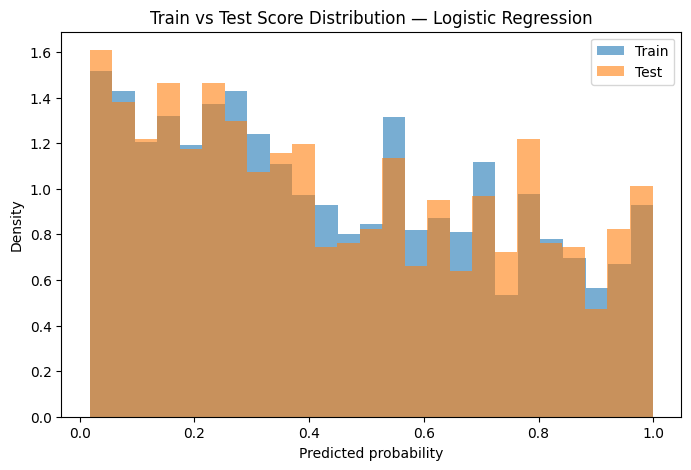

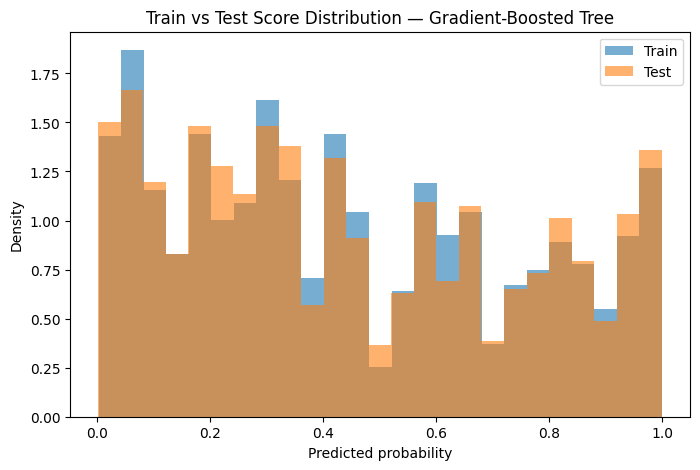

In [41]:
# ------------------------------------------------------------
# A4. Plot score distributions
# ------------------------------------------------------------

for name, model in models.items():
    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    plt.figure(figsize=(8, 5))
    plt.hist(train_prob, bins=25, alpha=0.6, label="Train", density=True)
    plt.hist(test_prob, bins=25, alpha=0.6, label="Test", density=True)
    plt.xlabel("Predicted probability")
    plt.ylabel("Density")
    plt.title(f"Train vs Test Score Distribution — {name}")
    plt.legend()
    plt.show()

## Part A Interpretation

The PSI and KS results compare the train and test distributions for the numeric features. In this dataset, I am mainly looking for features with higher PSI values or very different train and test means.

The MMD value gives a broader comparison after preprocessing and encoding the full feature set. I also compare the score distributions because even if raw features look similar, the model's output distribution can still shift.

If PSI is low, I would treat the feature as mostly stable. If PSI is moderate, I would monitor it. If PSI is high, I would treat it as a possible drift issue that may require retraining or further review.

## Part B: Generalization and Overfitting

In Part B, I compare train and test performance.

The main question is whether the models perform similarly on unseen data or whether they perform much better on training data. If training performance is much better than test performance, that suggests overfitting.

In [42]:
# ============================================================
# Part B: Generalization and overfitting
# ============================================================

gen_rows = []

for name, model in models.items():
    # Evaluate the same model on train and test data
    train_metrics = evaluate_classifier(model, X_train, y_train, name)
    test_metrics = evaluate_classifier(model, X_test, y_test, name)

    gen_rows.append({
        "model": name,

        "train_accuracy": train_metrics["accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "accuracy_gap": train_metrics["accuracy"] - test_metrics["accuracy"],

        "train_auc": train_metrics["auc"],
        "test_auc": test_metrics["auc"],
        "auc_gap": train_metrics["auc"] - test_metrics["auc"],

        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
        "brier_gap": train_metrics["brier"] - test_metrics["brier"],

        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "logloss_gap": train_metrics["logloss"] - test_metrics["logloss"],

        "train_mean_score": train_metrics["mean_score"],
        "test_mean_score": test_metrics["mean_score"],
    })

generalization_table = pd.DataFrame(gen_rows)

print("\n=== Part B: Generalization / Overfitting Summary ===")
print(generalization_table.round(4).to_string(index=False))


=== Part B: Generalization / Overfitting Summary ===
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap  train_mean_score  test_mean_score
  Logistic Regression          0.7539         0.7522        0.0017     0.8292    0.8329  -0.0037       0.1669      0.1642     0.0027         0.5016        0.4934       0.0082            0.4458           0.4476
Gradient-Boosted Tree          0.7748         0.7498        0.0250     0.8553    0.8309   0.0245       0.1530      0.1659    -0.0128         0.4612        0.4993      -0.0380            0.4458           0.4479


In [43]:
# ------------------------------------------------------------
# B2. Permutation importance
# ------------------------------------------------------------

# Permutation importance helps me see what features the model relies on.
# I check both train and test because a feature can look important in train
# but not generalize well to test.

for name, model in models.items():
    print(f"\n=== Part B2: Permutation Importance on Train — {name} ===")

    pi_train = permutation_importance_table(
        model,
        X_train,
        y_train,
        scoring="roc_auc"
    )

    print(pi_train.head(10).round(4).to_string(index=False))

    print(f"\n=== Part B2: Permutation Importance on Test — {name} ===")

    pi_test = permutation_importance_table(
        model,
        X_test,
        y_test,
        scoring="roc_auc"
    )

    print(pi_test.head(10).round(4).to_string(index=False))


=== Part B2: Permutation Importance on Train — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1458          0.0035
    age_factor           0.1103          0.0037
   race_factor           0.0200          0.0020
two_year_recid           0.0158          0.0014
  crime_factor           0.0018          0.0006
 gender_factor           0.0005          0.0002

=== Part B2: Permutation Importance on Test — Logistic Regression ===
       feature  importance_mean  importance_std
  priors_count           0.1578          0.0095
    age_factor           0.1036          0.0096
   race_factor           0.0182          0.0059
two_year_recid           0.0173          0.0035
  crime_factor           0.0042          0.0008
 gender_factor           0.0014          0.0005

=== Part B2: Permutation Importance on Train — Gradient-Boosted Tree ===
       feature  importance_mean  importance_std
  priors_count           0.1690          0.0043
    age_factor 

## Part B Interpretation

This section compares training performance with test performance.

If the train AUC or accuracy is much higher than the test AUC or accuracy, that would suggest overfitting. I also look at log loss and Brier score because accuracy alone does not tell the full story.

The permutation importance tables show which variables each model depends on most. If a feature is very important in training but less important in testing, that may suggest the model learned a less stable pattern.

## Part C: Spurious-Correlation Probe

In Part C, I run counterfactual swaps.

The idea is simple: I change one selected feature while keeping the rest of the row the same. Then I check how much the predicted probability changes.

This does not prove discrimination by itself, but it helps detect whether the model is sensitive to attributes like race, gender, or charge degree.

In [44]:
# ============================================================
# Part C: Spurious-correlation probe
# ============================================================

# These are the same kinds of swaps discussed in the lecture pipeline.
# I include race, gender, and charge degree.
swap_specs = [
    ("race_factor", "African-American", "Caucasian"),
    ("gender_factor", "Female", "Male"),
    ("crime_factor", "F", "M"),
]

counterfactual_tables = {}

for name, model in models.items():
    shifts = []

    for feature_col, a, b in swap_specs:
        shift_result = pairwise_swap_shift(
            model,
            X_test,
            feature_col,
            a,
            b
        )

        shifts.append(shift_result)

    shift_table = pd.DataFrame(shifts)
    counterfactual_tables[name] = shift_table

    print(f"\n=== Part C: Counterfactual Swap Sensitivity — {name} ===")
    print(shift_table.round(4).to_string(index=False))


=== Part C: Counterfactual Swap Sensitivity — Logistic Regression ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0806
gender_factor                Female <-> Male        1235               0.0251
 crime_factor                        F <-> M        1235               0.0410

=== Part C: Counterfactual Swap Sensitivity — Gradient-Boosted Tree ===
      feature                           swap  n_affected  mean_abs_prob_shift
  race_factor African-American <-> Caucasian        1046               0.0976
gender_factor                Female <-> Male        1235               0.0888
 crime_factor                        F <-> M        1235               0.0699


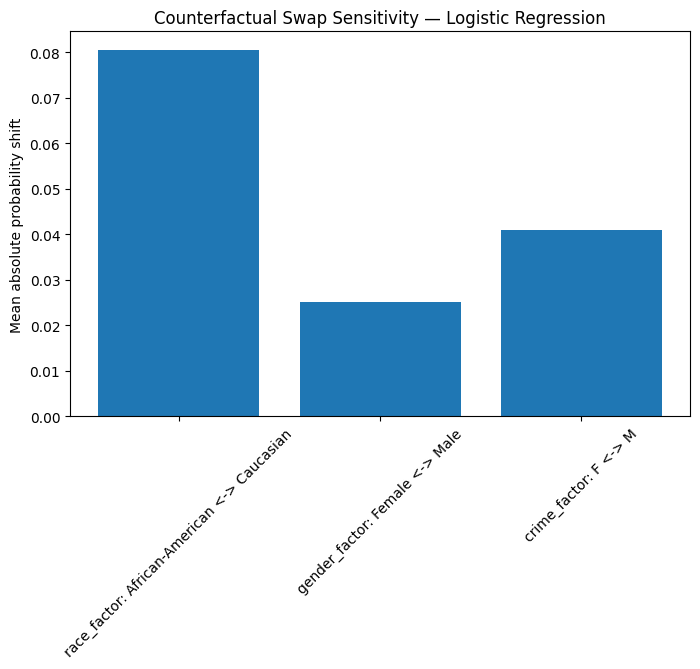

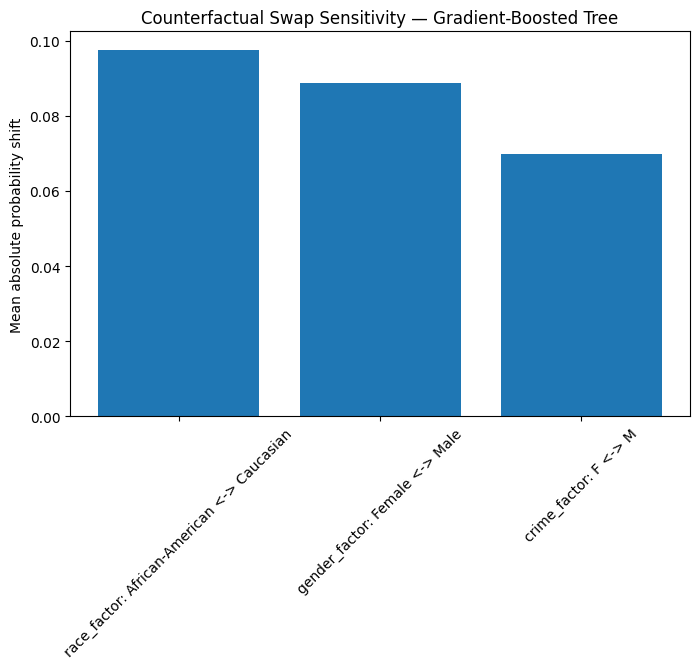

In [45]:
# ------------------------------------------------------------
# C2. Plot counterfactual swap sensitivity
# ------------------------------------------------------------

for name, shift_table in counterfactual_tables.items():
    plt.figure(figsize=(8, 5))
    plt.bar(
        shift_table["feature"] + ": " + shift_table["swap"],
        shift_table["mean_abs_prob_shift"]
    )
    plt.ylabel("Mean absolute probability shift")
    plt.title(f"Counterfactual Swap Sensitivity — {name}")
    plt.xticks(rotation=45)
    plt.show()

## Part C Interpretation

The counterfactual swap table shows how much predictions change after swapping selected attributes.

If the mean absolute probability shift is small, the model is not very sensitive to that swap. If it is large, the model may be relying more heavily on that attribute.

For race and gender, large shifts would be especially important because they may signal fairness or proxy-discrimination concerns. For charge degree, a shift is expected to some extent because it is directly related to risk classification, but the size of the shift still matters.

## Part D: Robustness and Stress Testing

In Part D, I test how stable the model is when `priors_count` changes.

This is important because a responsible model should not collapse or behave unpredictably when a realistic input changes. The model should degrade or change in a smooth and understandable way.

In [46]:
# ============================================================
# Part D: Robustness and stress testing
# ============================================================

stress_tables = {}

for name, model in models.items():
    stress_table = stress_test_priors(
        model,
        X_test,
        deltas=(0, 2, 5, 10)
    )

    stress_tables[name] = stress_table

    print(f"\n=== Part D1: Stress Test on priors_count — {name} ===")
    print(stress_table.round(4).to_string(index=False))


=== Part D1: Stress Test on priors_count — Logistic Regression ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4476            0.3970                0.4227
                  2          0.5372            0.5297                0.5368
                  5          0.6683            0.7159                0.7409
                 10          0.8435            0.9061                0.9247

=== Part D1: Stress Test on priors_count — Gradient-Boosted Tree ===
 delta_priors_count  mean_pred_prob  median_pred_prob  share_pred_high_risk
                  0          0.4479            0.4011                0.4089
                  2          0.5641            0.5678                0.5514
                  5          0.7070            0.8042                0.7328
                 10          0.8267            0.9534                0.8794


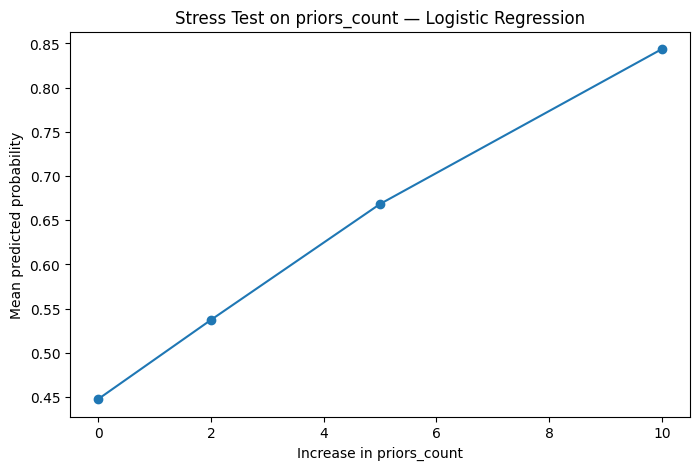

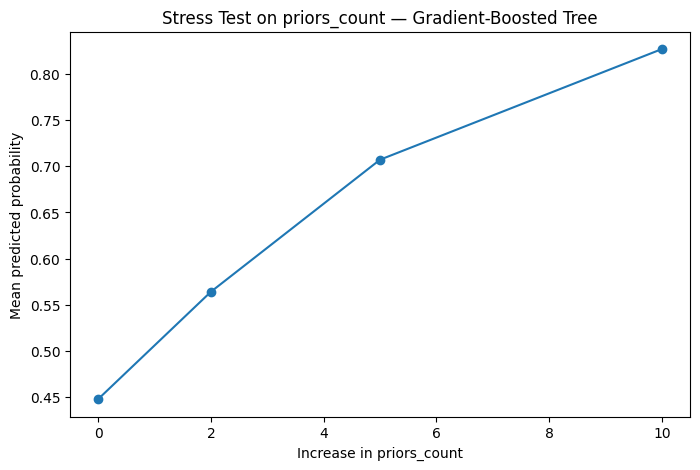

In [47]:
# ------------------------------------------------------------
# D2. Plot priors_count stress test
# ------------------------------------------------------------

for name, stress_table in stress_tables.items():
    plt.figure(figsize=(8, 5))
    plt.plot(
        stress_table["delta_priors_count"],
        stress_table["mean_pred_prob"],
        marker="o"
    )
    plt.xlabel("Increase in priors_count")
    plt.ylabel("Mean predicted probability")
    plt.title(f"Stress Test on priors_count — {name}")
    plt.show()

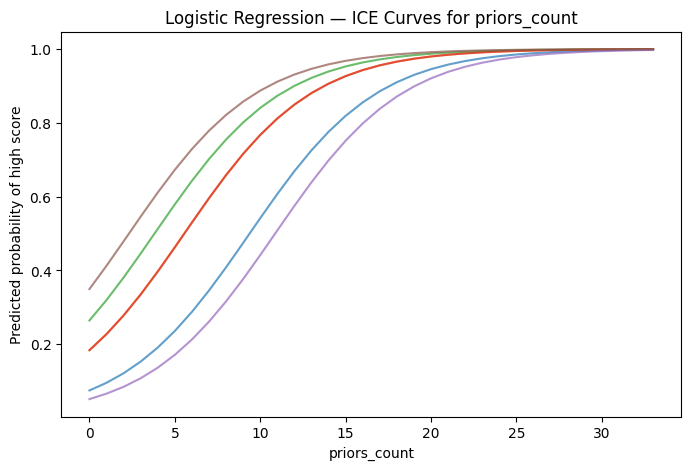

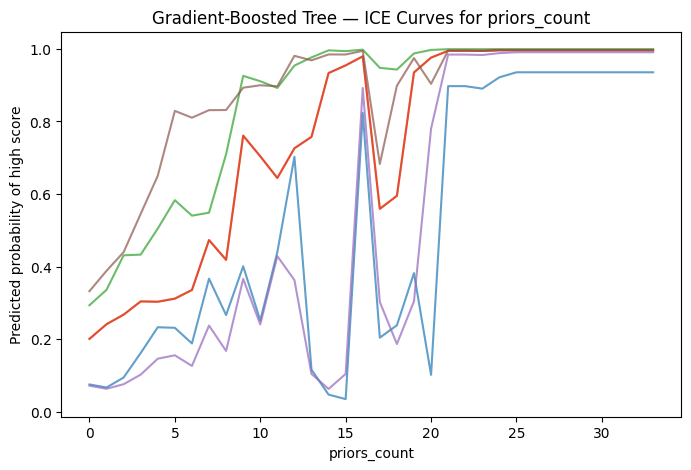

In [48]:
# ------------------------------------------------------------
# D3. ICE-style plots for priors_count
# ------------------------------------------------------------

# Create grid of values for priors_count
priors_grid = np.arange(
    int(X_test["priors_count"].min()),
    int(X_test["priors_count"].max()) + 1
)

plot_ice_numeric(
    lr_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=RANDOM_STATE,
    title="Logistic Regression — ICE Curves for priors_count"
)

plot_ice_numeric(
    gbt_pipeline,
    X_test,
    feature_col="priors_count",
    values=priors_grid,
    n_instances=6,
    random_state=RANDOM_STATE,
    title="Gradient-Boosted Tree — ICE Curves for priors_count"
)

In [49]:
# ------------------------------------------------------------
# D4. Global sensitivity index for priors_count
# ------------------------------------------------------------

lr_sens = global_sensitivity_index(
    lr_pipeline,
    X_test,
    "priors_count",
    priors_grid
)

gbt_sens = global_sensitivity_index(
    gbt_pipeline,
    X_test,
    "priors_count",
    priors_grid
)

sensitivity_table = pd.concat(
    [
        lr_sens.assign(model="Logistic Regression"),
        gbt_sens.assign(model="Gradient-Boosted Tree"),
    ],
    ignore_index=True
)

sensitivity_table = sensitivity_table[
    [
        "model",
        "feature",
        "sensitivity_index",
        "min_mean_score",
        "max_mean_score",
        "range_mean_score",
    ]
]

print("\n=== Part D4: Global Sensitivity Index for priors_count ===")
print(sensitivity_table.round(6).to_string(index=False))


=== Part D4: Global Sensitivity Index for priors_count ===
                model      feature  sensitivity_index  min_mean_score  max_mean_score  range_mean_score
  Logistic Regression priors_count           0.048791        0.287583        0.999167          0.711584
Gradient-Boosted Tree priors_count           0.041158        0.282523        0.980187          0.697664


## Part D Interpretation

The stress test shows how the average predicted probability changes when `priors_count` is increased.

The ICE curves show how individual predictions respond to different values of `priors_count`. This helps show whether all observations respond similarly or whether some people are affected more strongly.

The global sensitivity index summarizes how much the average prediction changes when `priors_count` is moved across a grid. If this value or the range of mean scores is large, the model may be highly sensitive to this feature.

## Part E: Slice-Based Evaluation

In Part E, I evaluate model performance across different slices of the data.

I check:

- Race  
- Gender  
- Age group  
- Charge degree  

This matters because a model can look good overall but still perform worse for specific subgroups.

In [50]:
# ============================================================
# Part E: Slice-based evaluation
# ============================================================

slice_features = [
    "race_factor",
    "gender_factor",
    "age_factor",
    "crime_factor"
]

slice_results_all = {}

for name, model in models.items():
    slice_tables = []

    for col in slice_features:
        temp_slice = slice_metrics(
            model,
            X_test,
            y_test,
            group_col=col
        )

        slice_tables.append(temp_slice)

    slice_eval = pd.concat(slice_tables, ignore_index=True)

    slice_eval = slice_eval.sort_values(
        ["slice_feature", "n"],
        ascending=[True, False]
    )

    slice_results_all[name] = slice_eval

    print(f"\n=== Part E: Slice-Based Evaluation — {name} ===")
    print(slice_eval.round(4).to_string(index=False))


=== Part E: Slice-Based Evaluation — Logistic Regression ===
slice_feature      slice_value    n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
   age_factor          25 - 45  695    0.7583 0.8326 0.1625 0.1658 0.3366              0.3871      0.4611
   age_factor  Greater than 45  272    0.8272 0.8492 0.1307 0.0498 0.5211              0.1618      0.2300
   age_factor     Less than 25  268    0.6604 0.7175 0.2023 0.6633 0.1529              0.7799      0.6338
 crime_factor                F  785    0.7376 0.8222 0.1721 0.2737 0.2524              0.5248      0.5137
 crime_factor                M  450    0.7778 0.8156 0.1503 0.1203 0.4627              0.2444      0.3324
gender_factor             Male 1000    0.7620 0.8448 0.1589 0.2135 0.2677              0.4480      0.4636
gender_factor           Female  235    0.7106 0.7832 0.1865 0.1606 0.4694              0.3149      0.3797
  race_factor African-American  634    0.7366 0.8195 0.1719 0.3870 0.1769              0.6

In [51]:
# ------------------------------------------------------------
# E2. Focused race slice evaluation
# ------------------------------------------------------------

race_slice_tables = {}

for name, model in models.items():
    race_slice = slice_metrics(
        model,
        X_test,
        y_test,
        group_col="race_factor"
    ).sort_values("n", ascending=False)

    race_slice_tables[name] = race_slice

    print(f"\n=== Race Slice Evaluation — {name} ===")
    print(race_slice.round(4).to_string(index=False))


=== Race Slice Evaluation — Logistic Regression ===
slice_feature      slice_value   n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
  race_factor African-American 634    0.7366 0.8195 0.1719 0.3870 0.1769              0.6435      0.5880
  race_factor        Caucasian 412    0.7500 0.7939 0.1626 0.1092 0.5625              0.2112      0.3168
  race_factor         Hispanic 108    0.8241 0.8311 0.1379 0.0633 0.4828              0.1852      0.3029
  race_factor            Other  71    0.8028 0.8524 0.1400 0.0185 0.7647              0.0704      0.2009
  race_factor            Asian   8    0.7500 0.6667 0.2027 0.0000 1.0000              0.0000      0.1564
  race_factor  Native American   2    0.5000 1.0000 0.1479 1.0000 0.0000              1.0000      0.6497

=== Race Slice Evaluation — Gradient-Boosted Tree ===
slice_feature      slice_value   n  accuracy    auc  brier    fpr    fnr  positive_rate_pred  mean_score
  race_factor African-American 634    0.7082 0.8077 

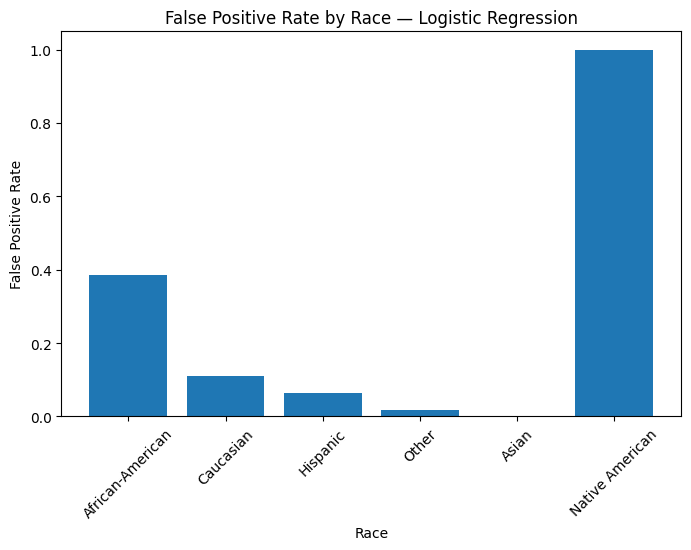

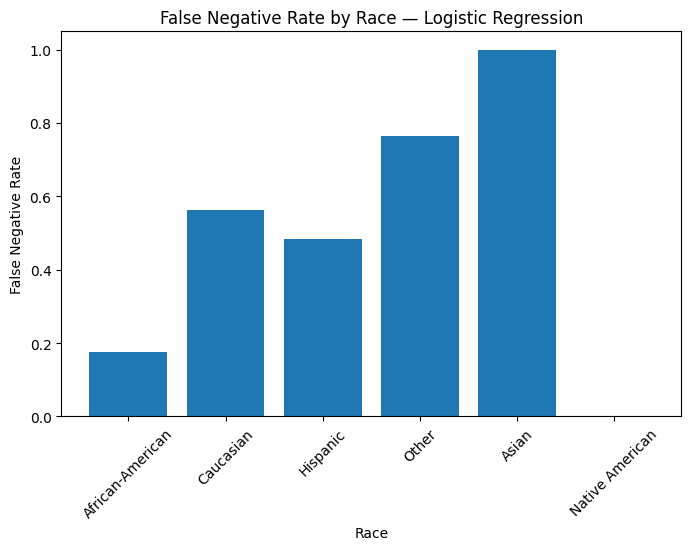

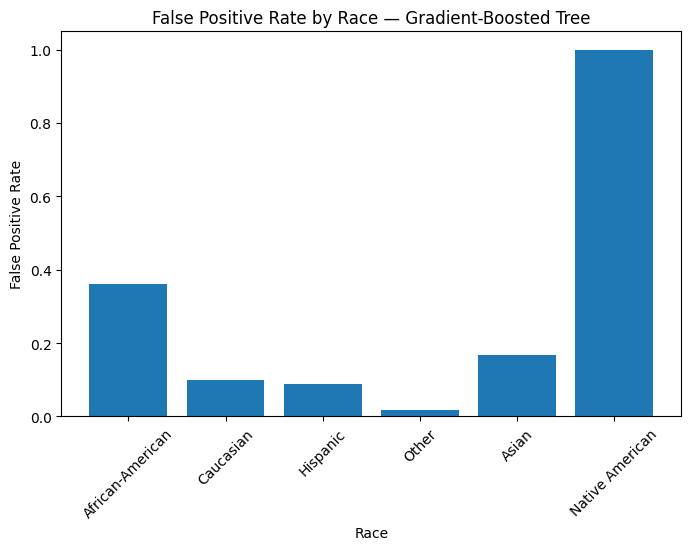

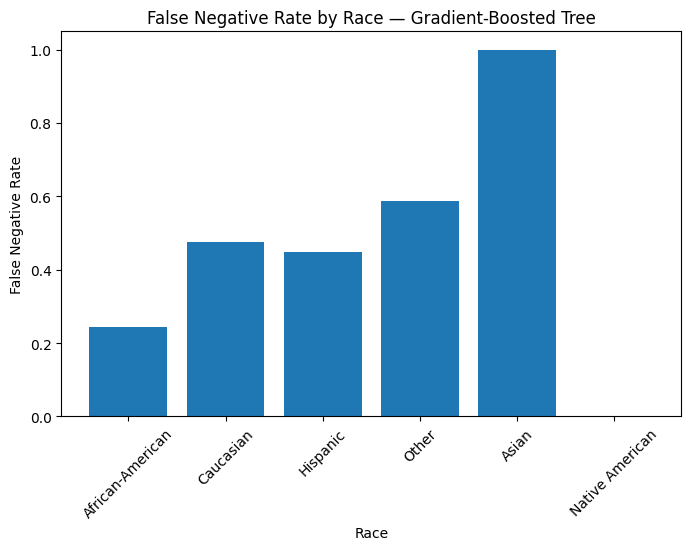

In [52]:
# ------------------------------------------------------------
# E3. Plot FPR and FNR by race
# ------------------------------------------------------------

for name, race_slice in race_slice_tables.items():
    plt.figure(figsize=(8, 5))
    plt.bar(
        race_slice["slice_value"].astype(str),
        race_slice["fpr"]
    )
    plt.xlabel("Race")
    plt.ylabel("False Positive Rate")
    plt.title(f"False Positive Rate by Race — {name}")
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.bar(
        race_slice["slice_value"].astype(str),
        race_slice["fnr"]
    )
    plt.xlabel("Race")
    plt.ylabel("False Negative Rate")
    plt.title(f"False Negative Rate by Race — {name}")
    plt.xticks(rotation=45)
    plt.show()

## Part E Interpretation

The slice-based evaluation shows whether model performance is similar across different groups.

I focus especially on false positive rate and false negative rate. A higher false positive rate means the model is more likely to incorrectly label people in that group as high score. A higher false negative rate means the model is more likely to miss people who actually received a high score.

This is important because average accuracy can hide subgroup-level failures. If one group has much worse error rates, that is a responsible machine learning concern even if the overall model performance looks acceptable.

## Final Summary

In this final section, I combine the main results into compact summary tables.

This helps connect the technical results to the audit question:  
Does the model remain reliable under drift, generalization gaps, counterfactual changes, stress testing, and subgroup evaluation?

In [53]:
# ============================================================
# Final summary tables
# ============================================================

print("\n==============================")
print("FINAL SUMMARY: PART A")
print("Input Drift Table")
print("==============================")
print(input_drift_table.round(4).to_string(index=False))

print("\n==============================")
print("FINAL SUMMARY: PART A")
print("Score Drift Table")
print("==============================")
print(score_drift_table.round(4).to_string(index=False))

print("\n==============================")
print("FINAL SUMMARY: PART A")
print("MMD")
print("==============================")
print(f"MMD^2(train, test) = {mmd_val:.6f}")

print("\n==============================")
print("FINAL SUMMARY: PART B")
print("Generalization Table")
print("==============================")
print(generalization_table.round(4).to_string(index=False))

print("\n==============================")
print("FINAL SUMMARY: PART C")
print("Counterfactual Swap Tables")
print("==============================")
for name, table in counterfactual_tables.items():
    print(f"\n{name}")
    print(table.round(4).to_string(index=False))

print("\n==============================")
print("FINAL SUMMARY: PART D")
print("Stress Test Tables")
print("==============================")
for name, table in stress_tables.items():
    print(f"\n{name}")
    print(table.round(4).to_string(index=False))

print("\n==============================")
print("FINAL SUMMARY: PART D")
print("Sensitivity Table")
print("==============================")
print(sensitivity_table.round(6).to_string(index=False))

print("\n==============================")
print("FINAL SUMMARY: PART E")
print("Race Slice Tables")
print("==============================")
for name, table in race_slice_tables.items():
    print(f"\n{name}")
    print(table.round(4).to_string(index=False))


FINAL SUMMARY: PART A
Input Drift Table
       feature  train_mean  test_mean    PSI PSI_interpretation  KS_stat  KS_pvalue
  priors_count       3.205     3.4121 0.0104             Stable   0.0335     0.2113
two_year_recid       0.458     0.4437 0.0008             Stable   0.0142     0.9862

FINAL SUMMARY: PART A
Score Drift Table
                model  train_mean_score  test_mean_score  PSI_score PSI_interpretation  KS_stat_score  KS_pvalue_score
  Logistic Regression            0.4458           0.4476     0.0040             Stable         0.0179           0.9040
Gradient-Boosted Tree            0.4458           0.4479     0.0037             Stable         0.0138           0.9901

FINAL SUMMARY: PART A
MMD
MMD^2(train, test) = -0.000272

FINAL SUMMARY: PART B
Generalization Table
                model  train_accuracy  test_accuracy  accuracy_gap  train_auc  test_auc  auc_gap  train_brier  test_brier  brier_gap  train_logloss  test_logloss  logloss_gap  train_mean_score  test_mean_sco

In [54]:
# ============================================================
# Compact audit table
# ============================================================

summary_rows = []

# Add drift results
for _, row in input_drift_table.iterrows():
    summary_rows.append({
        "audit_area": "Distribution Drift",
        "item": row["feature"],
        "main_metric": "PSI",
        "main_value": row["PSI"],
        "secondary_metric": "KS p-value",
        "secondary_value": row["KS_pvalue"],
        "student_note": row["PSI_interpretation"],
    })

# Add MMD
summary_rows.append({
    "audit_area": "Distribution Drift",
    "item": "Encoded Feature Space",
    "main_metric": "MMD^2",
    "main_value": mmd_val,
    "secondary_metric": "",
    "secondary_value": np.nan,
    "student_note": "Higher value means more overall feature distribution difference",
})

# Add generalization results
for _, row in generalization_table.iterrows():
    summary_rows.append({
        "audit_area": "Generalization",
        "item": row["model"],
        "main_metric": "AUC Gap",
        "main_value": row["auc_gap"],
        "secondary_metric": "Accuracy Gap",
        "secondary_value": row["accuracy_gap"],
        "student_note": "Large positive gap may suggest overfitting",
    })

# Add robustness sensitivity results
for _, row in sensitivity_table.iterrows():
    summary_rows.append({
        "audit_area": "Robustness",
        "item": row["model"],
        "main_metric": "Sensitivity Index",
        "main_value": row["sensitivity_index"],
        "secondary_metric": "Range Mean Score",
        "secondary_value": row["range_mean_score"],
        "student_note": "Higher values mean more sensitivity to priors_count",
    })

homework_summary = pd.DataFrame(summary_rows)

print("\n=== Compact Audit Summary Table ===")
print(homework_summary.round(6).to_string(index=False))


=== Compact Audit Summary Table ===
        audit_area                  item       main_metric  main_value secondary_metric  secondary_value                                                    student_note
Distribution Drift          priors_count               PSI    0.010355       KS p-value         0.211294                                                          Stable
Distribution Drift        two_year_recid               PSI    0.000820       KS p-value         0.986154                                                          Stable
Distribution Drift Encoded Feature Space             MMD^2   -0.000272                               NaN Higher value means more overall feature distribution difference
    Generalization   Logistic Regression           AUC Gap   -0.003694     Accuracy Gap         0.001672                      Large positive gap may suggest overfitting
    Generalization Gradient-Boosted Tree           AUC Gap    0.024467     Accuracy Gap         0.024964              

# Final Audit Conclusion

This notebook extends the Lecture 04 COMPAS pipeline by checking whether the models are reliable beyond average accuracy.

First, I tested distribution drift using PSI, KS tests, MMD, and score distributions. This helps show whether the train and test data look similar or whether the model may face changing data conditions.

Second, I compared train and test performance to check generalization. A large train-test gap would suggest overfitting, especially for the more flexible Gradient-Boosted Tree model.

Third, I used counterfactual swaps to test whether predictions change when race, gender, or charge degree are swapped. Large changes would be a warning sign that the model is sensitive to that feature.

Fourth, I stress-tested `priors_count` and created ICE curves and sensitivity summaries. This shows whether the model reacts smoothly or strongly when prior counts change.

Finally, I evaluated the models by slices such as race, gender, age group, and charge degree. This is important because a model can have good overall performance but still perform worse for specific groups.

Overall, I would not judge this model only by accuracy. A responsible model should also be stable under distribution shift, have reasonable generalization, avoid unexplained sensitivity to sensitive attributes, and perform fairly across important subgroups. If the audit shows large drift, large train-test gaps, large counterfactual shifts, or subgroup error differences, the model should be monitored, revised, or restricted before deployment.